In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

In [1]:
from pathlib import Path

import pandas as pd

In [3]:
hq_df = pd.read_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\all_filter_data_log\hq_csv\filtered_data\Vistral-7B-Chat+all_filter_data_mask_half_question.csv')
hq_df = hq_df.rename(columns={'retained': 'hq_retained'})
hq_df

,Question,predict,label,rouge_score,score,Grade,hq_retained
0,Hãy điền vào đoạn <MASKED> trong câu sau để ho...,quan dưới triều Tây Sơn.,quan dưới triều đại nào?,0.600000,0.600000,Văn 11,False
1,Hãy điền vào đoạn <MASKED> trong câu sau để ho...,B: Kêu gọi các Nho sĩ ra giúp nước,đời với mục đích gì?,0.000000,0.000000,Văn 11,True
2,Hãy điền vào đoạn <MASKED> trong câu sau để ho...,thời kỳ Trịnh Sâm lên ngôi vua.,hoàn cảnh đất nước như thế nào?,0.000000,0.000000,Văn 11,True
3,Hãy điền vào đoạn <MASKED> trong câu sau để ho...,[MASKED]\nA: Kẻ sĩ mai danh ẩn tích uổng phí ...,thái độ của sĩ phu Bắc Hà:,0.033333,0.034483,Văn 11,True
4,Hãy điền vào đoạn <MASKED> trong câu sau để ho...,của tác phẩm là một văn kiện quan trọng thể h...,của Chiếu cầu hiền là:,0.108108,0.114286,Văn 11,True
...,...,...,...,...,...,...,...
1252,Hãy điền vào đoạn <MASKED> trong câu sau để ho...,mãn phương trình z^2 = 3z + 2.\n\nĐáp án là: ...,mãn (1 - i)z - 1 + 5i = 0 là,0.242424,0.000000,Toán 12,True
1253,Hãy điền vào đoạn <MASKED> trong câu sau để ho...,[MASKED] là:\n\nT = i2016 + 3\n\nĐáp án là: ...,i216 + i16 + i6 + 1 ta có,0.333333,0.000000,Toán 12,True
1254,Hãy điền vào đoạn <MASKED> trong câu sau để ho...,"5i) = 0.\n\nĐầu tiên, ta có thể đơn giản hoá ...",2i) = 9 + 16i . Giá trị biểu thức T = |x -...,0.130435,0.060606,Toán 12,True
1255,Hãy điền vào đoạn <MASKED> trong câu sau để ho...,"[MASKED] = 0, trong đó z là một số phức.\n\nĐ...",z − = 4i - 20. Môđun của z là,0.153846,0.100000,Toán 12,True


In [7]:
wa_df = pd.read_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\all_filter_data_log\wa_csv\filtered_data\Vistral-7B-Chat+all_filter_data_mask_wrong_answer.csv')
wa_df = wa_df.rename(columns={'retained': 'wa_retained'})
wa_df = wa_df['wa_retained']
wa_df

0        True
1       False
2        True
3        True
4       False
        ...  
1252    False
1253     True
1254     True
1255     True
1256    False
Name: wa_retained, Length: 1257, dtype: bool

,Unnamed: 0,Câu hỏi,A,B,C,D,Answer,Grade
0,0,Ngô Thì Nhậm từng làm quan dưới triều đại nào?,"Triều Mạc, Lê, Trịnh","Triều Lê, Mạc, Tây Sơn","Triều Lê, Trịnh, Tây Sơn","Triều Mạc, Lê, Trịnh, Tây Sơn",B,Văn 11
1,1,Chiếu cầu hiền ra đời với mục đích gì?,Kêu gọi những người theo Nguyễn Ánh ra giúp Tâ...,Kêu gọi các Nho sĩ ra giúp nước,Kêu gọi những người giỏi võ ra giúp nước,Kêu gọi kẻ sĩ Bắc Hà ra cộng tác với triều đìn...,D,Văn 11
2,2,Chiếu cầu hiền ra đời trong hoàn cảnh đất nước...,Khi triều đại Lê – Trịnh sụp đổ,Khi Trịnh Sâm lên ngôi vua,Nguyễn Huệ lên ngôi vua,Khi triều đại Tây Sơn sụp đổ,C,Văn 11
3,3,Đáp án không thể hiện đúng thái độ của sĩ phu ...,Kẻ sĩ mai danh ẩn tích uổng phí tài năng,Người ra làm quan thì giữ mình không dám nói t...,Nhiều người có tài năng còn chưa chịu ra giúp ...,Nhiều người ngưỡng mộ tài năng của vua Quang T...,D,Văn 11
4,4,Giá trị nội dung của Chiếu cầu hiền là:,Tác phẩm là một văn kiện quan trọng thể hiện c...,Tác phẩm là một văn kiện quan trọng thể hiện c...,Tác phẩm là một văn kiện quan trọng thể hiện c...,Tác phẩm là một văn kiện quan trọng thể hiện c...,A,Văn 11
...,...,...,...,...,...,...,...,...
1252,1276,Phần thực và phần ảo của số phức z tho...,3 và –2,3 và 2,3 và – 2i,3 và 2i,A,Toán 12
1253,1277,Giá trị của biểu thức T = i2016 + i216 + ...,3,4,5,6,A,Toán 12
1254,1278,"Các số thực x, y thỏa mãn đẳng thức x(3...",0,1,3,5,D,Toán 12
1255,1279,Cho số phức z thoả mãn (1 + 2i)².z + z − = 4i ...,4,5,6,10,B,Toán 12


In [10]:
df = pd.concat([hq_df, wa_df], axis=1)
df['retained'] = df['hq_retained'] & df['wa_retained']
df = df.drop(columns=['hq_retained', 'wa_retained'])
df[df['retained'] == True]['Grade'].value_counts()

Grade
Toán 12       70
GDCD 11       69
Toán 11       67
Văn 8         50
Lịch sử 11    50
Địa lý 11     46
Văn 11        45
Địa lý 6      45
Địa lý 7      38
Toán 10       36
Địa lý 9      32
Sinh học 9    29
Vật lý 12     23
Vật lý 11     10
Name: count, dtype: int64

In [12]:
retain = df['retained']
retain

0       False
1       False
2        True
3        True
4       False
        ...  
1252    False
1253     True
1254     True
1255     True
1256    False
Name: retained, Length: 1257, dtype: bool

In [26]:
question = pd.read_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\all_filter_data.csv')
question['retained'] = retain
question = question.drop(columns=question.columns[question.columns.str.contains('Unnamed')])
question

,Câu hỏi,A,B,C,D,Answer,Grade,retained
0,Ngô Thì Nhậm từng làm quan dưới triều đại nào?,"Triều Mạc, Lê, Trịnh","Triều Lê, Mạc, Tây Sơn","Triều Lê, Trịnh, Tây Sơn","Triều Mạc, Lê, Trịnh, Tây Sơn",B,Văn 11,False
1,Chiếu cầu hiền ra đời với mục đích gì?,Kêu gọi những người theo Nguyễn Ánh ra giúp Tâ...,Kêu gọi các Nho sĩ ra giúp nước,Kêu gọi những người giỏi võ ra giúp nước,Kêu gọi kẻ sĩ Bắc Hà ra cộng tác với triều đìn...,D,Văn 11,False
2,Chiếu cầu hiền ra đời trong hoàn cảnh đất nước...,Khi triều đại Lê – Trịnh sụp đổ,Khi Trịnh Sâm lên ngôi vua,Nguyễn Huệ lên ngôi vua,Khi triều đại Tây Sơn sụp đổ,C,Văn 11,True
3,Đáp án không thể hiện đúng thái độ của sĩ phu ...,Kẻ sĩ mai danh ẩn tích uổng phí tài năng,Người ra làm quan thì giữ mình không dám nói t...,Nhiều người có tài năng còn chưa chịu ra giúp ...,Nhiều người ngưỡng mộ tài năng của vua Quang T...,D,Văn 11,True
4,Giá trị nội dung của Chiếu cầu hiền là:,Tác phẩm là một văn kiện quan trọng thể hiện c...,Tác phẩm là một văn kiện quan trọng thể hiện c...,Tác phẩm là một văn kiện quan trọng thể hiện c...,Tác phẩm là một văn kiện quan trọng thể hiện c...,A,Văn 11,False
...,...,...,...,...,...,...,...,...
1252,Phần thực và phần ảo của số phức z tho...,3 và –2,3 và 2,3 và – 2i,3 và 2i,A,Toán 12,False
1253,Giá trị của biểu thức T = i2016 + i216 + ...,3,4,5,6,A,Toán 12,True
1254,"Các số thực x, y thỏa mãn đẳng thức x(3...",0,1,3,5,D,Toán 12,True
1255,Cho số phức z thoả mãn (1 + 2i)².z + z − = 4i ...,4,5,6,10,B,Toán 12,True


In [18]:
domain_df = pd.read_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\data_done\domain.csv')
domain_df

,Question,A,B,C,D,Answer
0,"Trong giờ ra chơi, A trêu đùa và đánh B gây ch...",Báo với cô giáo chủ nhiệm để tìm cách giải quyết.,Mặc kệ vì không liên quan đến mình.,Cùng với A đánh B cho vui.,Chạy đi chỗ khác chơi.,A
1,Trên đường đi học về em nhìn thấy một thanh ni...,Lờ đi chỗ khác và coi như không biết.,"Nhờ sự giúp đỡ của người lớn, đưa em bé đó đến...",Đèo em bé đó đến gặp công an.,Đạp thật nhanh về nhà.,B
2,Câu thành ngữ: Gió chiều nào theo chiều ấy nói...,Không tôn trọng lẽ phải.,Không trung thực.,Không chín chắn.,Không có ý thức.,C
3,Em rèn tính liêm khiết trong học tập là:,Nhiệt tình giúp đỡ mọi người mà không tính toá...,"Làm giàu bằng chính sức lực, tài năng của mình",Nhặt được của rơi trả lại cho người bị mất,Tất cả đáp án trên,D
4,"Không hám danh, hám lợi, không nhỏ nhen, ích k...",Liêm khiết.,Công bằng.,Lẽ phải.,Khiêm tốn.,A
...,...,...,...,...,...,...
2102,Tiêu chí nào dưới đây biểu thị sự đa dạng sinh...,Số lượng loài trong quần thể.,Số lượng cá thể trong quần xã.,Số lượng loài.,Số lượng cá thể trong một loài.,C
2103,Động vật nào dưới đây thụ tinh ngoài?,Cá chép.,Chim bồ câu.,Rùa núi vàng.,Thỏ hoang.,A
2104,Đặc điểm nào dưới đâu giúp cơ thể thằn lằn giữ...,Da có lớp vảy sừng bao bọc.,Mắt có tuyến lệ giữ ẩm.,Hậu thận và trực tràng có khả năng hấp thụ lại...,Cả A và C đều đúng.,D
2105,"Trong các nguyên nhân sau, đâu là nguyên nhân ...",Do các hoạt động của con người.,Do các loại thiên tai xảy ra.,Do khả năng thích nghi của sinh vật bị suy giả...,Do các loại dịch bệnh bất thường.,A


In [20]:
domain_filter = pd.read_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\original_filtered.csv')
domain_filter[['retained', 'Grade']]

,retained,Grade
0,True,GDCD 8
1,True,GDCD 8
2,True,GDCD 8
3,True,GDCD 8
4,True,GDCD 8
...,...,...
2102,False,Sinh 7
2103,True,Sinh 7
2104,True,Sinh 7
2105,True,Sinh 7


In [21]:
domain = pd.concat([domain_df, domain_filter[['retained', 'Grade']]], axis=1)

In [27]:
domain = domain.rename(columns={'Question': 'Câu hỏi'})
domain

,Câu hỏi,A,B,C,D,Answer,retained,Grade
0,"Trong giờ ra chơi, A trêu đùa và đánh B gây ch...",Báo với cô giáo chủ nhiệm để tìm cách giải quyết.,Mặc kệ vì không liên quan đến mình.,Cùng với A đánh B cho vui.,Chạy đi chỗ khác chơi.,A,True,GDCD 8
1,Trên đường đi học về em nhìn thấy một thanh ni...,Lờ đi chỗ khác và coi như không biết.,"Nhờ sự giúp đỡ của người lớn, đưa em bé đó đến...",Đèo em bé đó đến gặp công an.,Đạp thật nhanh về nhà.,B,True,GDCD 8
2,Câu thành ngữ: Gió chiều nào theo chiều ấy nói...,Không tôn trọng lẽ phải.,Không trung thực.,Không chín chắn.,Không có ý thức.,C,True,GDCD 8
3,Em rèn tính liêm khiết trong học tập là:,Nhiệt tình giúp đỡ mọi người mà không tính toá...,"Làm giàu bằng chính sức lực, tài năng của mình",Nhặt được của rơi trả lại cho người bị mất,Tất cả đáp án trên,D,True,GDCD 8
4,"Không hám danh, hám lợi, không nhỏ nhen, ích k...",Liêm khiết.,Công bằng.,Lẽ phải.,Khiêm tốn.,A,True,GDCD 8
...,...,...,...,...,...,...,...,...
2102,Tiêu chí nào dưới đây biểu thị sự đa dạng sinh...,Số lượng loài trong quần thể.,Số lượng cá thể trong quần xã.,Số lượng loài.,Số lượng cá thể trong một loài.,C,False,Sinh 7
2103,Động vật nào dưới đây thụ tinh ngoài?,Cá chép.,Chim bồ câu.,Rùa núi vàng.,Thỏ hoang.,A,True,Sinh 7
2104,Đặc điểm nào dưới đâu giúp cơ thể thằn lằn giữ...,Da có lớp vảy sừng bao bọc.,Mắt có tuyến lệ giữ ẩm.,Hậu thận và trực tràng có khả năng hấp thụ lại...,Cả A và C đều đúng.,D,True,Sinh 7
2105,"Trong các nguyên nhân sau, đâu là nguyên nhân ...",Do các hoạt động của con người.,Do các loại thiên tai xảy ra.,Do khả năng thích nghi của sinh vật bị suy giả...,Do các loại dịch bệnh bất thường.,A,True,Sinh 7


In [30]:
final = pd.concat([question, domain], axis=0)
final[final['retained'] == True]['Grade'].value_counts()

Grade
Toán 12      70
GDCD 11      69
Địa lý 6     67
Toán 11      67
Địa lý 11    62
             ..
Toán 4        5
Toán 2        4
Ngữ văn 4     3
Toán 3        2
Hóa 10        1
Name: count, Length: 64, dtype: int64

In [37]:
import matplotlib.pyplot as plt
def plot_dropped(df):
    fig, ax = plt.subplots(figsize = (60, 20))

    count = {}
    count_drop = {}
    for key in df['Grade'].unique():
        count[key] = [df[df['Grade'] == key].shape[0]]
        count_drop[key] = [df[(df['Grade'] == key) & (df['retained'] == False)].shape[0]]

    # count = pd.DataFrame.from_dict(count, orient='index')
    # count_drop = pd.DataFrame.from_dict(count_drop, orient='index')
    # plt.bar(count.index, count[0], color = 'b')
    # plt.bar(count_drop.index, count_drop[0], color = 'r')

    for grade, value in count.items():
        p = ax.bar(grade, value[0], color = 'b')
        ax.bar_label(p, label_type = 'edge')

    for grade, value in count_drop.items():
        p = ax.bar(grade, value[0], color = 'r')
        ax.bar_label(p, label_type = 'edge')

    # plt.title(f'{name}')
    # if drop_math:
    #     plt.savefig(DATA_PATH / 'plots_drop' / f'{name}_no_math.png')
    # else:
    #     plt.savefig(DATA_PATH / 'plots_drop' / f'{name}.png')
    plt.close()
    return fig

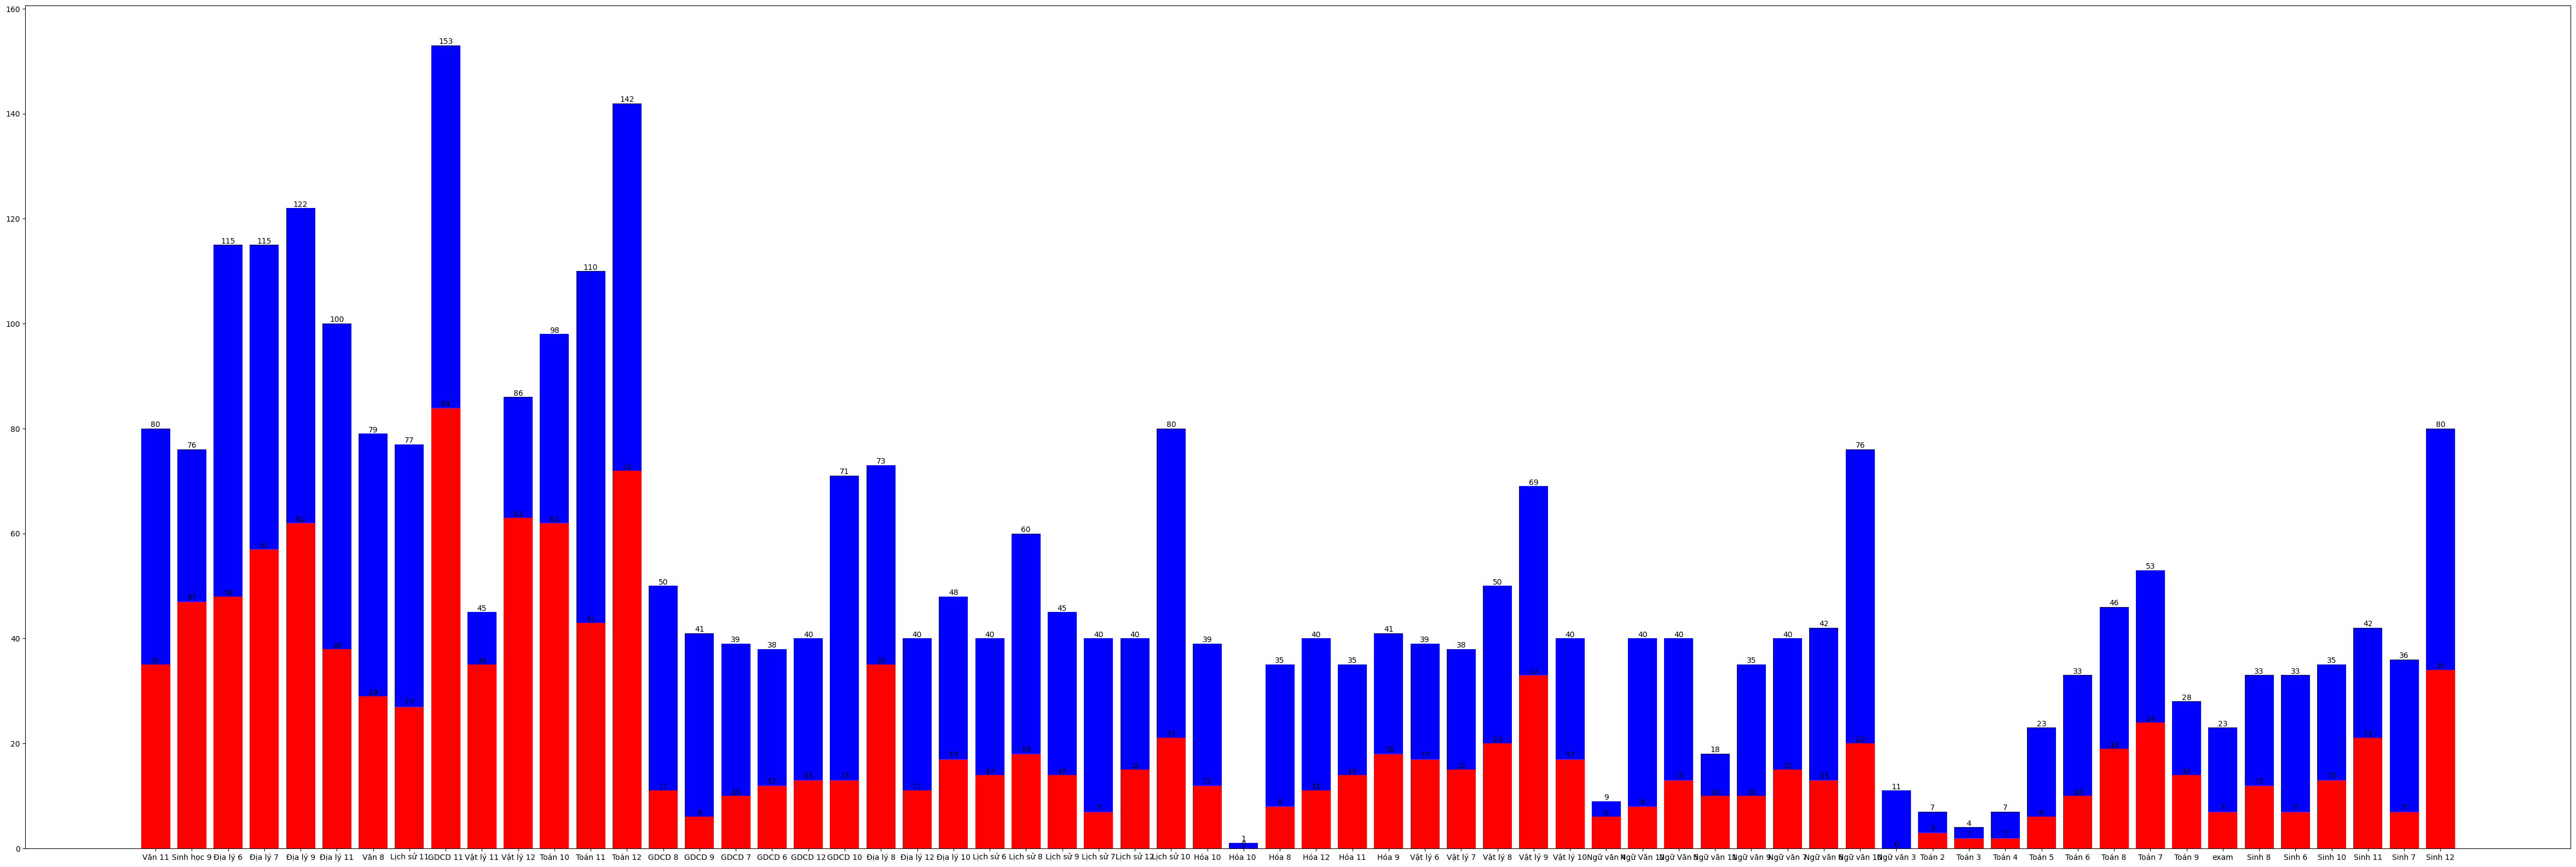

In [38]:
plot_dropped(final)

In [41]:

print(sorted(final['Grade'].unique()))

['GDCD 10', 'GDCD 11', 'GDCD 12', 'GDCD 6', 'GDCD 7', 'GDCD 8', 'GDCD 9', 'Hóa 10', 'Hóa 10 ', 'Hóa 11', 'Hóa 12', 'Hóa 8', 'Hóa 9', 'Lịch sử 10', 'Lịch sử 11', 'Lịch sử 12', 'Lịch sử 6', 'Lịch sử 7', 'Lịch sử 8', 'Lịch sử 9', 'Ngữ Văn 12', 'Ngữ Văn 5', 'Ngữ văn 10', 'Ngữ văn 11', 'Ngữ văn 3', 'Ngữ văn 4', 'Ngữ văn 6', 'Ngữ văn 7', 'Ngữ văn 9', 'Sinh 10', 'Sinh 11', 'Sinh 12', 'Sinh 6', 'Sinh 7', 'Sinh 8', 'Sinh học 9', 'Toán 10', 'Toán 11', 'Toán 12', 'Toán 2', 'Toán 3', 'Toán 4', 'Toán 5', 'Toán 6', 'Toán 7', 'Toán 8', 'Toán 9', 'Văn 11', 'Văn 8', 'Vật lý 10', 'Vật lý 11', 'Vật lý 12', 'Vật lý 6', 'Vật lý 7', 'Vật lý 8', 'Vật lý 9', 'exam', 'Địa lý 10', 'Địa lý 11', 'Địa lý 12', 'Địa lý 6', 'Địa lý 7', 'Địa lý 8', 'Địa lý 9']


In [42]:
final.to_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\final-0.1.csv', index=False)